## Problem: What are the factors and features of a listing that make an AirBnb listing more expensive?

### Problem 1: What are the features/facilities/ammenities of a property that affects its price?

In [1]:
#Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()

from collections import Counter

In [2]:
#Importing the listing dataset
listingsDF = pd.read_csv("../data/listings.csv")
listingsDF.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [3]:
print("Data type : ", type(listingsDF))
print("Data dims : ", listingsDF.shape)

Data type :  <class 'pandas.core.frame.DataFrame'>
Data dims :  (3818, 92)


### Data Cleaning

In [4]:
#selecting below varibales for further analysis
listingDF = listingsDF[['id','name','summary','longitude','latitude','space','description','instant_bookable','neighborhood_overview','neighbourhood_cleansed','host_id','host_name','host_since',
                 'host_response_time','street', 'zipcode','review_scores_rating','property_type','room_type','accommodates','bathrooms','bedrooms','beds','reviews_per_month','amenities','cancellation_policy','number_of_reviews','price']]
listingDF.head()

,id,name,summary,longitude,latitude,space,description,instant_bookable,neighborhood_overview,neighbourhood_cleansed,...,room_type,accommodates,bathrooms,bedrooms,beds,reviews_per_month,amenities,cancellation_policy,number_of_reviews,price
0,241032,Stylish Queen Anne Apartment,NaN,-122.371025,47.636289,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,f,NaN,West Queen Anne,...,Entire home/apt,4,1.0,1.0,1.0,4.07,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",moderate,207,$85.00
1,953595,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,-122.365666,47.639123,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,f,"Queen Anne is a wonderful, truly functional vi...",West Queen Anne,...,Entire home/apt,4,1.0,1.0,1.0,1.48,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",strict,43,$150.00
2,3308979,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,-122.369483,47.629724,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,f,Upper Queen Anne is a charming neighborhood fu...,West Queen Anne,...,Entire home/apt,11,4.5,5.0,7.0,1.15,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",strict,20,$975.00
3,7421966,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,-122.369279,47.638473,NaN,A charming apartment that sits atop Queen Anne...,f,NaN,West Queen Anne,...,Entire home/apt,3,1.0,0.0,2.0,NaN,"{Internet,""Wireless Internet"",Kitchen,""Indoor ...",flexible,0,$100.00
4,278830,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,-122.372471,47.632918,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,f,We are in the beautiful neighborhood of Queen ...,West Queen Anne,...,Entire home/apt,6,2.0,3.0,3.0,0.89,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",strict,38,$450.00


In [5]:
#replace NaN values with 0
listingDF.fillna(0, inplace=True)

#extract prices from listingDF into priceDF
priceDF = listingDF['price']
# Create an empty prices list
prices=[]

#convert prices from listingDF into float values and append it in prices list
for p in priceDF:
    p = float(p[1:].replace(',',''))
    prices.append(p)
    
#replace the price column in the original listingDF with the new prices
listingDF['price'] = prices

/var/folders/9p/gm2n68xn7n1bhds792y57yg40000gn/T/ipykernel_25005/1607208495.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  listingDF.fillna(0, inplace=True)
/var/folders/9p/gm2n68xn7n1bhds792y57yg40000gn/T/ipykernel_25005/1607208495.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  listingDF['price'] = prices


In [6]:
#remove listings with 0 for  bedrooms, bathrooms, accomodates, price, beds, review_scores_rating, reviews_per_month
listingDF = listingDF[listingDF.bedrooms > 0]
listingDF = listingDF[listingDF.bathrooms > 0]
listingDF = listingDF[listingDF.accommodates > 0]
listingDF = listingDF[listingDF.price > 0]
listingDF = listingDF[listingDF.beds > 0]
listingDF = listingDF[listingDF.review_scores_rating > 0]
listingDF = listingDF[listingDF.reviews_per_month > 0]

listingDF.head()

,id,name,summary,longitude,latitude,space,description,instant_bookable,neighborhood_overview,neighbourhood_cleansed,...,room_type,accommodates,bathrooms,bedrooms,beds,reviews_per_month,amenities,cancellation_policy,number_of_reviews,price
0,241032,Stylish Queen Anne Apartment,0,-122.371025,47.636289,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,f,0,West Queen Anne,...,Entire home/apt,4,1.0,1.0,1.0,4.07,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",moderate,207,85.0
1,953595,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,-122.365666,47.639123,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,f,"Queen Anne is a wonderful, truly functional vi...",West Queen Anne,...,Entire home/apt,4,1.0,1.0,1.0,1.48,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",strict,43,150.0
2,3308979,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,-122.369483,47.629724,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,f,Upper Queen Anne is a charming neighborhood fu...,West Queen Anne,...,Entire home/apt,11,4.5,5.0,7.0,1.15,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",strict,20,975.0
4,278830,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,-122.372471,47.632918,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,f,We are in the beautiful neighborhood of Queen ...,West Queen Anne,...,Entire home/apt,6,2.0,3.0,3.0,0.89,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",strict,38,450.0
5,5956968,Private unit in a 1920s mansion,We're renting out a small private unit of one ...,-122.366174,47.630525,If you include a bit of your background in you...,We're renting out a small private unit of one ...,f,This part of Queen Anne has wonderful views an...,West Queen Anne,...,Private room,2,1.0,1.0,1.0,2.45,"{""Wireless Internet"",""Free Parking on Premises...",strict,17,120.0


#### Analyzing the listings based on room types. 

Number of room types : 3

room_type
Entire home/apt    1805
Private room        947
Shared room          91
Name: count, dtype: int64


/var/folders/9p/gm2n68xn7n1bhds792y57yg40000gn/T/ipykernel_25005/2794623134.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.catplot(x = "room_type", data = listingDF, kind = "count", palette="Set2")


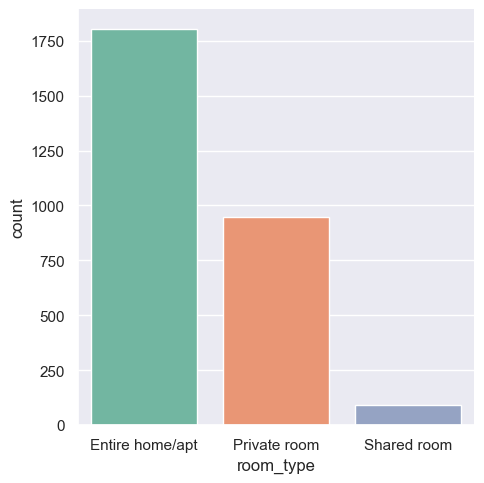

In [7]:
#number of room types
print("Number of room types :", len(listingDF["room_type"].unique()))
print()

#number of listings of each room type
print(listingDF["room_type"].value_counts())
sb.catplot(x = "room_type", data = listingDF, kind = "count", palette="Set2")

After cleaning, 2,843 listings remain. Most are **entire homes/apartments (1,805, 63%)**, followed by **private rooms (947, 33%)**, with **shared rooms** being rare (91, 3%). Most hosts in Seattle list their whole property.

#### Analyzing the listings based on the property type.

Number of property types : 15

property_type
House              1403
Apartment          1194
Townhouse            78
Condominium          68
Bed & Breakfast      26
Loft                 22
Cabin                17
Other                13
Camper/RV             8
Boat                  5
Tent                  4
Bungalow              2
Dorm                  1
Chalet                1
Treehouse             1
Name: count, dtype: int64


/var/folders/9p/gm2n68xn7n1bhds792y57yg40000gn/T/ipykernel_25005/503570737.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.catplot(x = "property_type", data = listingDF, kind = "count", palette="Set2", height = 8, aspect = 2)


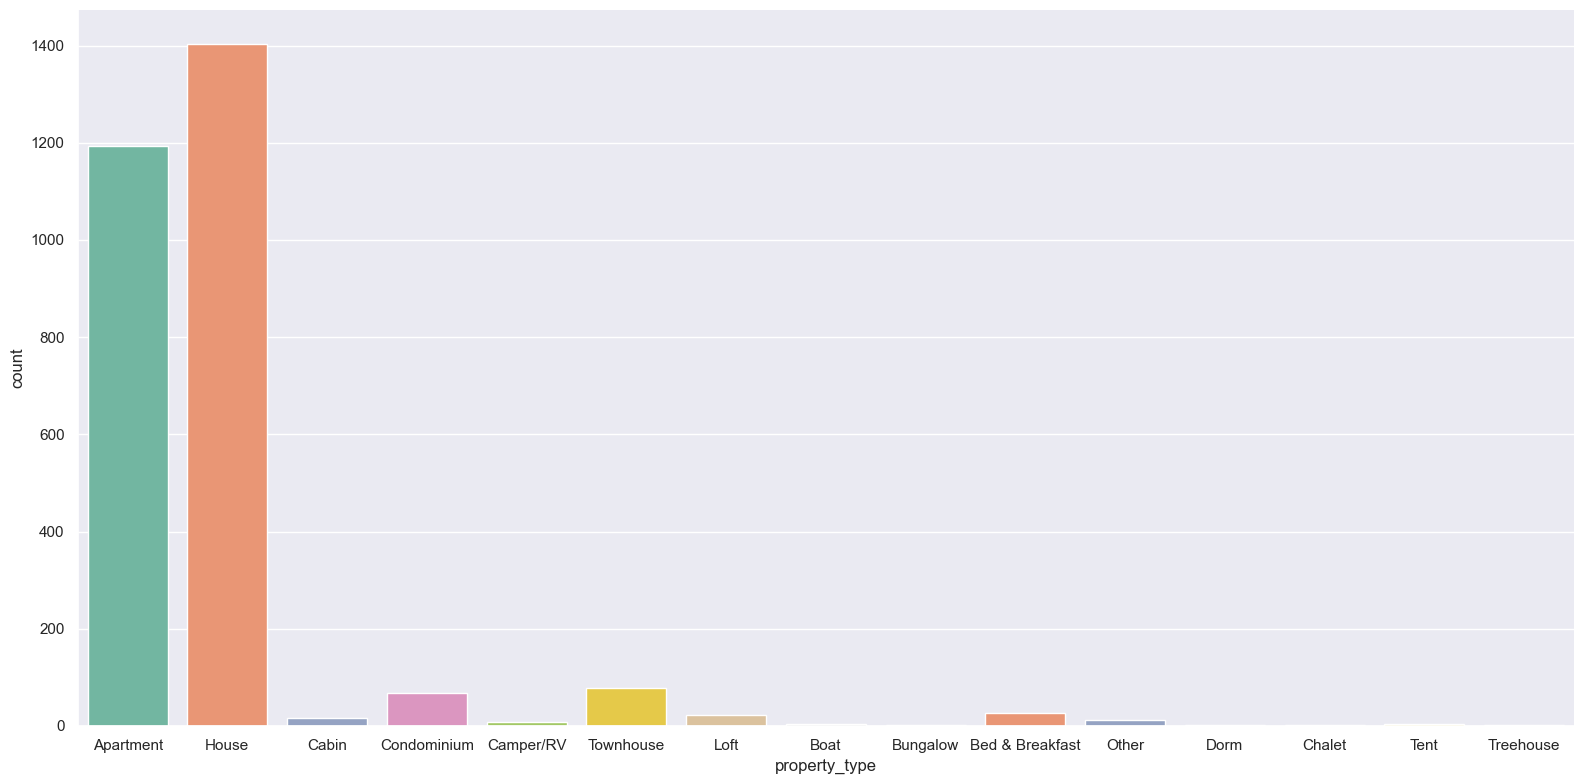

In [8]:
#number of property types
print("Number of property types :", len(listingDF["property_type"].unique()))
print()

#number of listings of each room type
print(listingDF["property_type"].value_counts())
sb.catplot(x = "property_type", data = listingDF, kind = "count", palette="Set2", height = 8, aspect = 2)

**Houses (1,403) and apartments (1,194) make up 91% of all listings.** The next most common types are townhouses (78) and condominiums (68), and nine of the 15 property types have 13 or fewer listings each. Combined with the room-type counts, most Seattle listings are entire apartments or entire houses. Next we check whether these listing types relate to price.

#### Analyzing the prices for the different room and property types.

In [9]:
#checking out the mean prices for the different room and property types
roomProperty_DF = listingDF.groupby(['property_type','room_type']).price.mean()
roomProperty_DF = roomProperty_DF.reset_index()
roomProperty_DF=roomProperty_DF.sort_values('price',ascending=[0])
roomProperty_DF.head()

,property_type,room_type,price
6,Boat,Entire home/apt,513.333333
19,House,Entire home/apt,194.824859
29,Townhouse,Entire home/apt,189.818182
22,Loft,Entire home/apt,178.933333
15,Condominium,Entire home/apt,170.490566


<Axes: xlabel='room_type', ylabel='property_type'>

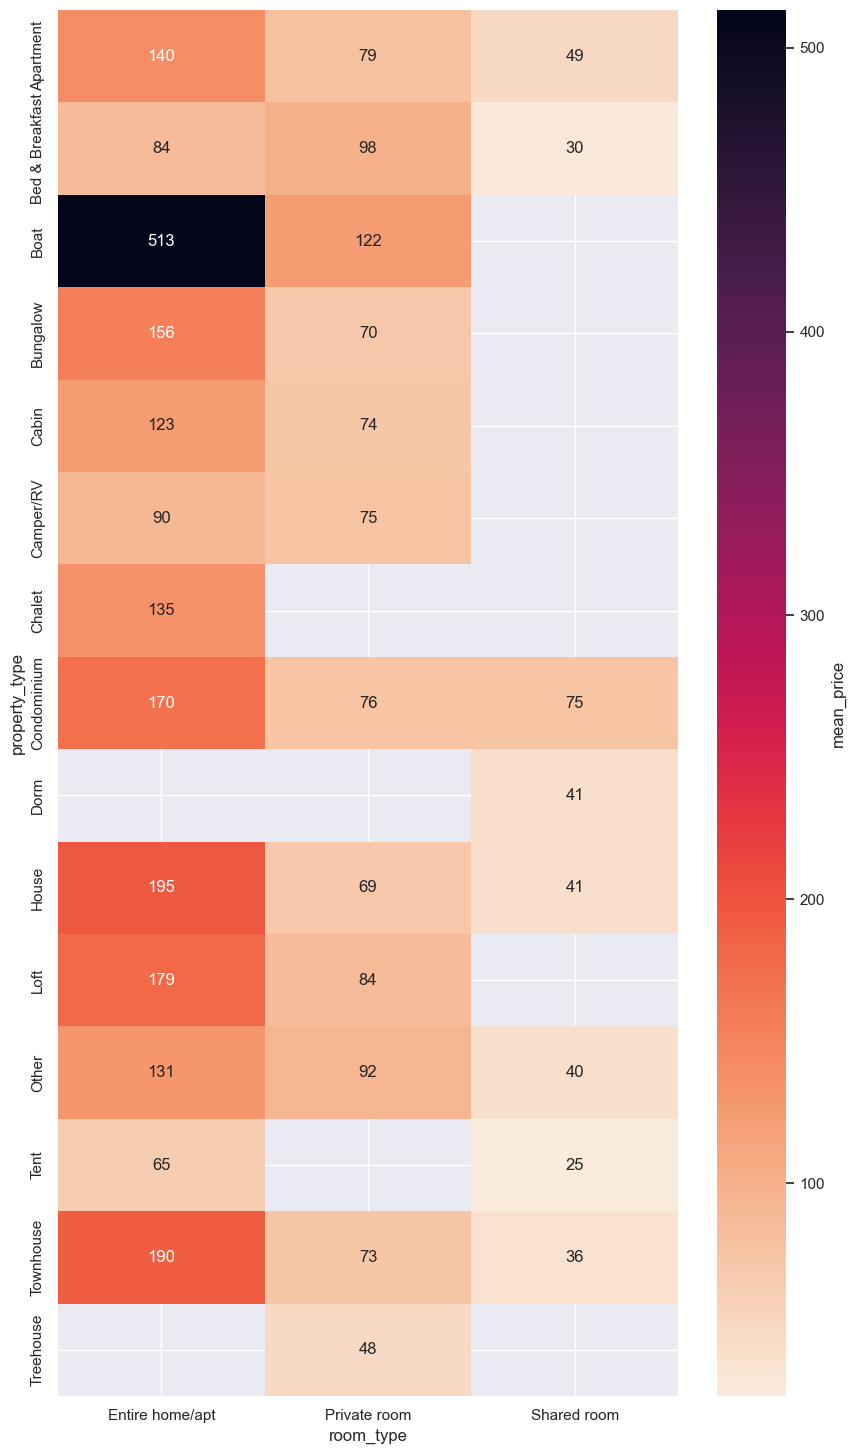

In [10]:
#plotting a heatmap of the mean price for room type and a property type

plt.figure(figsize = (10,18))
sb.heatmap(listingDF.groupby(['property_type', 'room_type']).price.mean().unstack(), annot=True, fmt=".0f", cmap = sb.cm.rocket_r, cbar_kws={'label': 'mean_price'})


The heatmap shows the mean price for each property type / room type combination (darker = more expensive).

- **Room type drives price more than property type.** Within every property type the order is the same: entire home > private room > shared room. For example, houses: $195 / $69 / $41, and apartments: $140 / $79 / $49.
- **Entire houses cost more than entire apartments** ($195 vs $140 on average). For private and shared rooms, houses and apartments are priced similarly.
- **Boats show the highest mean ($513 for entire home), but this is based on only 3 listings** (two of them at $680 and $775), so it is not a reliable pattern. Cells built on very few listings should be read with caution.

The summary below confirms the room-type gap using both mean and median (the median is less affected by a few very expensive listings).

In [11]:
#mean and median price for each room type
listingDF.groupby('room_type').price.agg(['count', 'mean', 'median']).round(0)

,count,mean,median
room_type,,,
Entire home/apt,1805,164.0,137.0
Private room,947,73.0,68.0
Shared room,91,44.0,40.0


#### Anaylzing the listings based on the number of bedrooms.

<Axes: xlabel='bedrooms', ylabel='price'>

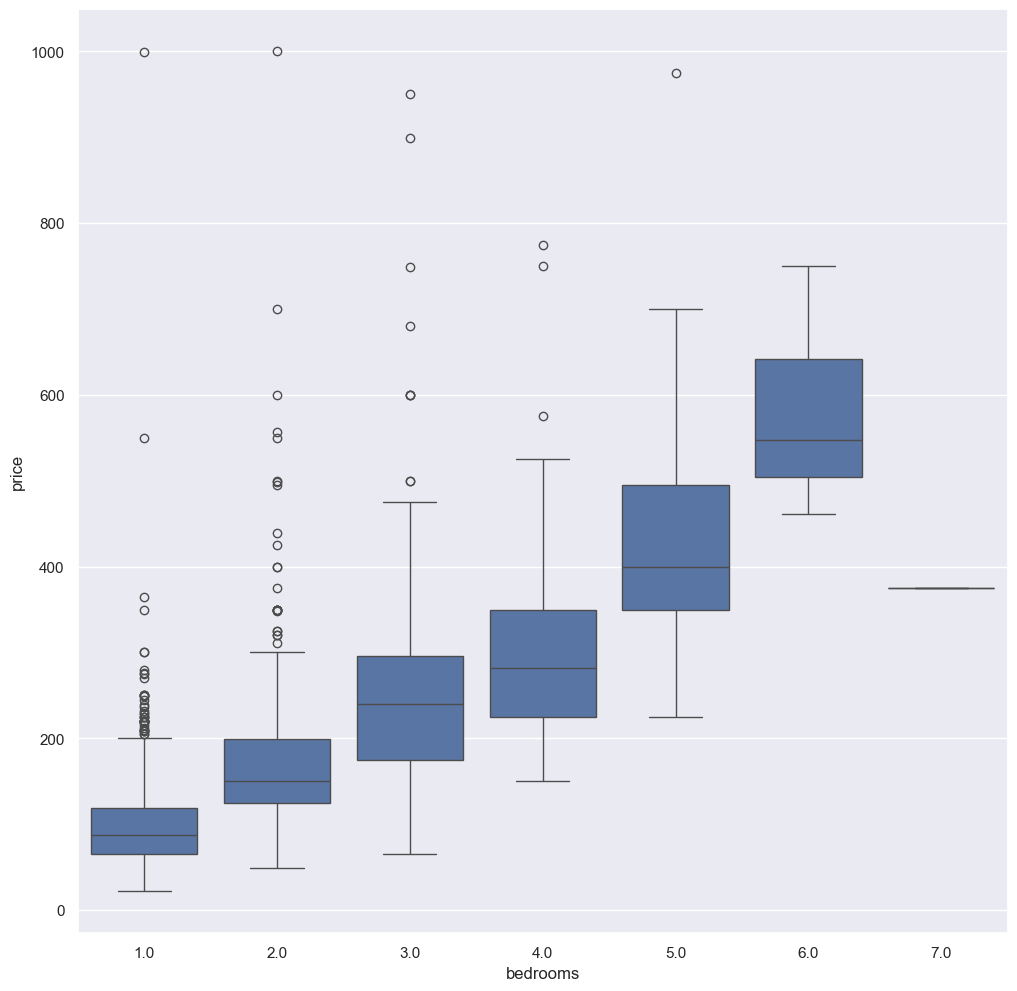

In [12]:
#plotting a boxplot to quickly see if there is any trend between price and no. bedrooms
plt.figure(figsize=(12,12))
sb.boxplot(x='bedrooms', y='price', data=listingDF[['bedrooms', 'price']])

The boxplots show a clear upward trend between the number of bedrooms and price. Next we look at bedrooms together with property type.

In [13]:
#creating a number of rooms vs property type dataframe
noRoomDF = listingDF[['property_type', 'bedrooms']]
noRoomDF.head(n=15)

,property_type,bedrooms
0,Apartment,1.0
1,Apartment,1.0
2,House,5.0
4,House,3.0
5,House,1.0
6,House,1.0
7,Cabin,1.0
8,Apartment,1.0
9,Apartment,1.0
10,House,1.0


<Axes: xlabel='bedrooms', ylabel='property_type'>

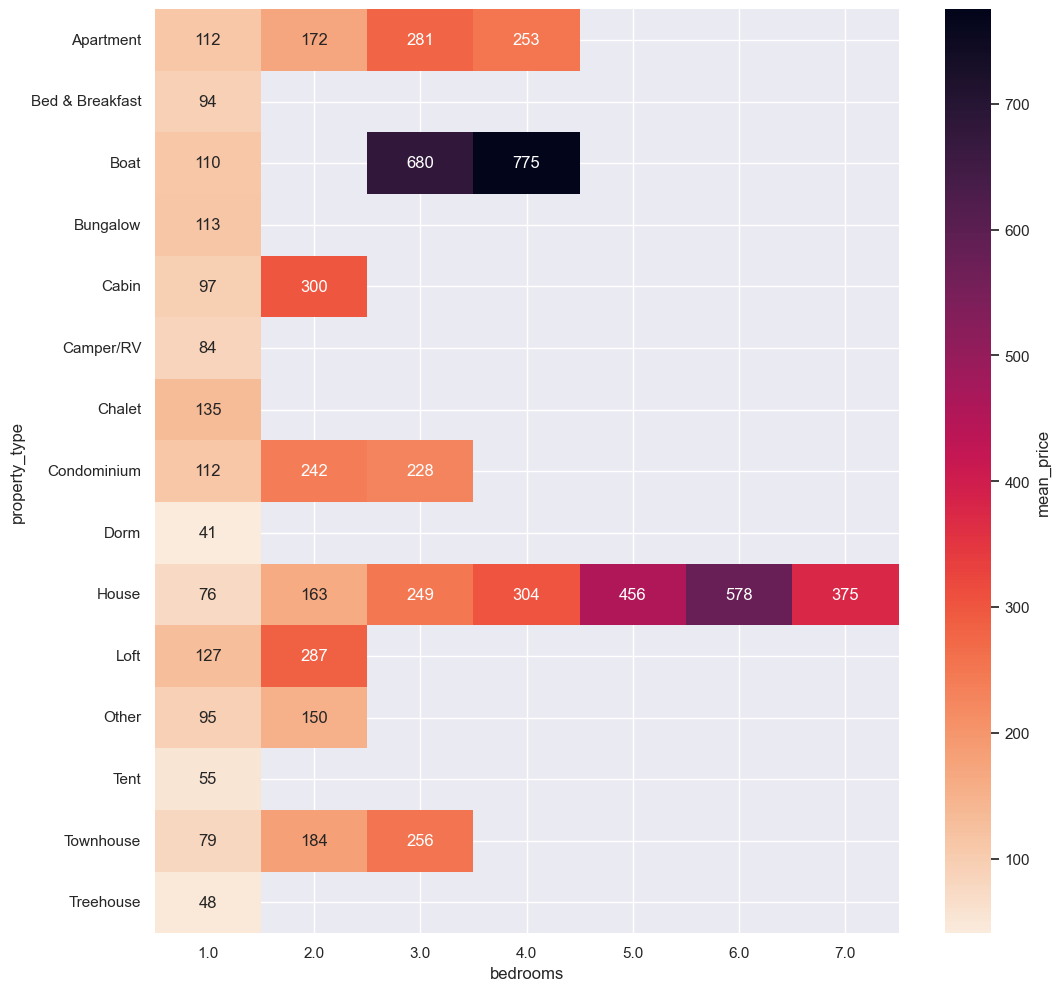

In [14]:
#plotting a heatmap of prices with number of bedrooms for listings

plt.figure(figsize=(12,12))
sb.heatmap(listingDF.groupby(['property_type', 'bedrooms']).price.mean().unstack(),annot=True, fmt=".0f", cmap = sb.cm.rocket_r, cbar_kws={'label': 'mean_price'})


The heatmap and boxplots confirm that price increases with the number of bedrooms. The only exception is the 7-bedroom house, which is cheaper than the 5- and 6-bedroom listings. To understand why, we look at how many listings there are for each number of bedrooms.

In [15]:
#number of bedrooms
print("Number of bedrooms :", len(listingDF["bedrooms"].unique()))
print()
print("BedRms|Listings")
#number of listings of each room type
print(listingDF["bedrooms"].value_counts())

Number of bedrooms : 7

BedRms|Listings
bedrooms
1.0    1999
2.0     532
3.0     236
4.0      52
5.0      17
6.0       6
7.0       1
Name: count, dtype: int64


In [16]:
#mean and median price for each number of bedrooms
listingDF.groupby('bedrooms').price.agg(['count', 'mean', 'median']).round(0)

,count,mean,median
bedrooms,,,
1.0,1999,95.0,87.0
2.0,532,171.0,150.0
3.0,236,252.0,240.0
4.0,52,311.0,282.0
5.0,17,456.0,400.0
6.0,6,578.0,548.0
7.0,1,375.0,375.0


- **Price rises steadily with bedrooms**: the median goes from **$87 (1 bedroom) → $150 (2) → $240 (3) → $283 (4) → $400 (5) → $548 (6)**, roughly +$60–80 per extra bedroom.
- **70% of listings (1,999) have 1 bedroom**, and only 24 listings have 5 or more.
- There is **only one 7-bedroom listing** ($375), so the dip at 7 bedrooms is a single outlier rather than a real trend.

So far, we can see that room type, property type and number of bedrooms have some effect on the price of a listing. We will now analyse if any specific ammenity in the property results in higher prices.

#### Analyzing if any particular ammenity results in higher prices.

##### We are going to analyze the textual data of ammenities by finding the words that appear most frequently in ammenities in the most expensive listings.

In [17]:
import os, nltk
from nltk.data import find

# Put NLTK data inside the project so VS Code always finds it
NLTK_DIR = os.path.join(os.getcwd(), "nltk_data")
os.makedirs(NLTK_DIR, exist_ok=True)
# Prepend so it’s searched first
nltk.data.path.insert(0, NLTK_DIR)

# Packages required by your code
needed = {
    "punkt":        "tokenizers/punkt",
    "punkt_tab":    "tokenizers/punkt_tab",   # <-- newer NLTK needs this too
    "stopwords":    "corpora/stopwords",
    "wordnet":      "corpora/wordnet",
    "omw-1.4":      "corpora/omw-1.4",
}

# Download any missing package
for pkg, resource in needed.items():
    try:
        find(resource)
    except LookupError:
        nltk.download(pkg, download_dir=NLTK_DIR, quiet=True)

# (Optional) sanity check
print("NLTK search paths:", nltk.data.path)
for pkg, resource in needed.items():
    try:
        find(resource)
        print(f"OK: {pkg}")
    except LookupError:
        print(f"MISSING: {pkg}")


NLTK search paths: ['/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/code/nltk_data', '/Users/rutikakadam/nltk_data', '/Users/rutikakadam/.cache/uv/builds-v0/.tmp0wFpSv/nltk_data', '/Users/rutikakadam/.cache/uv/builds-v0/.tmp0wFpSv/share/nltk_data', '/Users/rutikakadam/.cache/uv/builds-v0/.tmp0wFpSv/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']
OK: punkt
OK: punkt_tab
OK: stopwords
MISSING: wordnet
MISSING: omw-1.4


In [18]:
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, wordpunct_tokenize

df = listingsDF.copy()

# Clean price
df['price'] = (df['price'].astype(str)
               .str.replace(r'[^0-9.]', '', regex=True)
               .replace('', pd.NA).astype(float))

amen = df[['amenities','price','id']].dropna(subset=['amenities'])
amen = amen.sort_values('price', ascending=False).head(30)

text = ' '.join(re.sub('[^a-zA-Z]+', ' ', a) for a in amen['amenities']).lower()

stop = set(stopwords.words('english'))
wnl = WordNetLemmatizer()

# Try punkt; if still missing, fall back to wordpunct (no downloads needed)
try:
    tokens = word_tokenize(text)
except LookupError:
    tokens = [t for t in wordpunct_tokenize(text) if t.isalpha()]

tokens = [w for w in tokens if w.isalpha() and w not in stop]
tokens = [wnl.lemmatize(w) for w in tokens]
amenities_words = ' '.join(tokens)


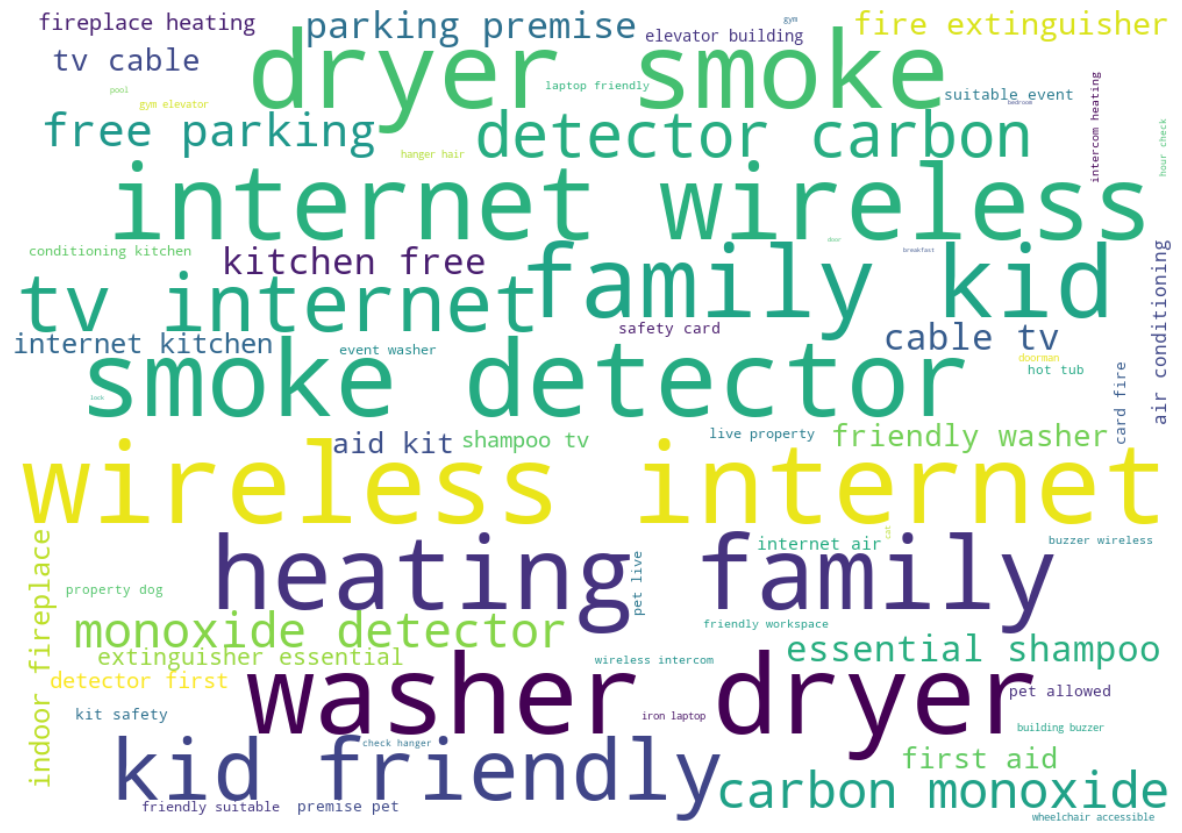

In [19]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=1000, height=700, background_color="white").generate(amenities_words)

plt.figure(figsize=(15,15))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


The word cloud is dominated by words such as *washer*, *dryer*, *heating*, *internet*, *smoke detector* and *parking*. However, a word cloud only shows what is **common** among expensive listings, not what is **distinctive** about them. Many of these amenities appear in almost every listing, so the table below compares how often each amenity appears in the 30 most expensive listings versus all listings.

In [20]:
#comparing how often each amenity appears in the 30 most expensive listings vs all listings
amenity_list = ['Washer', 'Dryer', 'Heating', 'Wireless Internet', 'Smoke Detector', 'Free Parking',
                'Kid Friendly', 'Hot Tub', 'Gym', 'Elevator', 'Pool']

amenityDF = pd.DataFrame({
    'top_30_listings': [amen['amenities'].str.contains(a, regex=False).mean() for a in amenity_list],
    'all_listings': [df['amenities'].str.contains(a, regex=False).mean() for a in amenity_list],
}, index=amenity_list)
amenityDF['difference'] = amenityDF['top_30_listings'] - amenityDF['all_listings']
(amenityDF.sort_values('difference', ascending=False) * 100).round(0)

,top_30_listings,all_listings,difference
Kid Friendly,83.0,51.0,32.0
Dryer,100.0,82.0,18.0
Washer,97.0,78.0,18.0
Hot Tub,20.0,8.0,12.0
Free Parking,67.0,57.0,10.0
Elevator,30.0,21.0,9.0
Gym,20.0,12.0,8.0
Smoke Detector,90.0,86.0,4.0
Pool,7.0,4.0,3.0
Heating,97.0,95.0,2.0


Heating, wireless internet and smoke detectors appear in almost every listing (over 85%), so they tell us little about price. The amenities that are clearly **over-represented** among the most expensive listings are **Kid Friendly** (83% vs 51%), **Washer/Dryer** (97–100% vs about 80%), **Hot Tub** (20% vs 8%), **Elevator** (30% vs 21%) and **Gym** (20% vs 12%). Kid Friendly and washer/dryer likely reflect that the most expensive listings are large entire homes aimed at families and groups. With only 30 listings in the top group these are indications rather than proof, which is why amenities are tested properly in the machine learning notebook.

From all the analysis above, we can say a few things:

1. **Room type has the biggest influence on price.** Most hosts (63%) list their entire property, and entire homes/apartments are the most expensive (median $137), about twice the price of a private room ($68). Shared rooms are the cheapest ($40).


2. **Property type also matters, but less than room type.** Houses and apartments make up 91% of listings. Entire houses are more expensive than entire apartments ($195 vs $140 mean), while private rooms cost about the same in both. Boats have the highest mean price, but there are only 3 entire-home boat listings, so this is not a reliable finding.


3. **Price increases with the number of bedrooms**, from a median of $87 for 1 bedroom to $548 for 6 bedrooms. The single 7-bedroom listing is an outlier.


4. **Common amenities do not explain price.** Heating, wireless internet and smoke detectors appear in over 85% of all listings, so they do not distinguish expensive listings. Amenities that are over-represented among the most expensive listings include **Kid Friendly** (83% vs 51% of all listings), **Washer/Dryer** (97–100% vs about 80%), **Hot Tub** (20% vs 8%) and **Gym** (20% vs 12%). **The amenities will be further explored in the machine learning part of the project.**